# 🚘 Used BMW Price Prediction Using Machine Learning

## Statistical Analysis, Outlier Detection and Regression Modeling

---

### Author

**Ayşenur Cingöz**

Department of Statistics

---

### Project Type

Machine Learning | Regression | Data Analysis | Statistics

---

### Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- Streamlit

---

### Objective

The primary objective of this project is to develop a machine learning model capable of predicting the selling price of used BMW vehicles based on their technical characteristics.

In addition to predictive modeling, this project focuses on statistical data analysis by investigating the distribution of the target variable, detecting outliers using the Interquartile Range (IQR) method, and improving model performance through logarithmic transformation.

Two different regression algorithms (Random Forest and XGBoost) will be trained and evaluated using multiple performance metrics, including MAE, RMSE and R².

Finally, the best-performing model will be deployed as an interactive web application using Streamlit.

In [31]:
# 1. Importing Required Libraries

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

import joblib

%matplotlib inline
plt.style.use("ggplot")

## Why These Libraries?

The project combines statistical analysis, data visualization and machine learning techniques.

- **Pandas** is used for data manipulation.
- **NumPy** provides numerical computations.
- **Matplotlib** and **Seaborn** are used to visualize the data.
- **Scikit-learn** provides preprocessing tools and machine learning algorithms.
- **XGBoost** is included as a powerful gradient boosting regression algorithm.
- **Joblib** is used to save the trained machine learning model for deployment.

# 2. Loading the Dataset

In [34]:
df = pd.read_csv("bmw.csv")

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


## Dataset Description

The dataset contains information about used BMW vehicles listed for sale.

Each observation represents one vehicle and includes several explanatory variables describing its technical specifications.

The prediction target is the **selling price** of each vehicle.

# 3. Dataset Overview

In [35]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10781, 9)


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 986.8 KB


In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,10781.0,2017.078935,2.349038,1996.0,2016.0,2017.0,2019.0,2020.0
price,10781.0,22733.408867,11415.528189,1200.0,14950.0,20462.0,27940.0,123456.0
mileage,10781.0,25496.986550,25143.192559,1.0,5529.0,18347.0,38206.0,214000.0
tax,10781.0,131.702068,61.510755,0.0,135.0,145.0,145.0,580.0
mpg,10781.0,56.399035,31.336958,5.5,45.6,53.3,62.8,470.8
engineSize,10781.0,2.167767,0.552054,0.0,2.0,2.0,2.0,6.6


In [38]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

## Data Types and Missing Values

Before building the machine learning models, it is important to examine the data types of each variable and identify whether the dataset contains any missing values.

This step ensures that each feature has the appropriate data type and that the dataset is complete enough for further statistical analysis and model training.

In [40]:
data_info = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum()
})

data_info

,Data Type,Missing Values
model,str,0
year,int64,0
price,int64,0
transmission,str,0
mileage,int64,0
fuelType,str,0
tax,int64,0
mpg,float64,0
engineSize,float64,0


### Interpretation

The dataset contains three categorical variables (`model`, `transmission`, and `fuelType`) and six numerical variables (`year`, `price`, `mileage`, `tax`, `mpg`, and `engineSize`).

No missing values were detected in any of the variables. Therefore, no data imputation or missing value treatment was required before proceeding with the analysis.

## Interpretation

The dataset consists of **10,781 observations** and **9 variables**.

No missing values were identified, indicating that the dataset is complete and suitable for statistical analysis.

The variables include both categorical and numerical features, making the dataset appropriate for regression-based machine learning algorithms.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is one of the most important stages of every data science project.

The primary objective of this section is to investigate the statistical properties of the dataset, understand the distribution of the variables, identify potential outliers, and determine whether additional preprocessing techniques are required before model training.

Since the prediction target of this project is the vehicle price, the analysis begins with an examination of the distribution of the target variable.

## 4.1 Distribution of the Target Variable

Before training any regression model, it is important to examine whether the target variable follows a normal distribution.

Highly skewed target variables may negatively affect model performance by giving excessive importance to extreme observations.

Therefore, the distribution of vehicle prices is visualized using a histogram and Kernel Density Estimation (KDE).

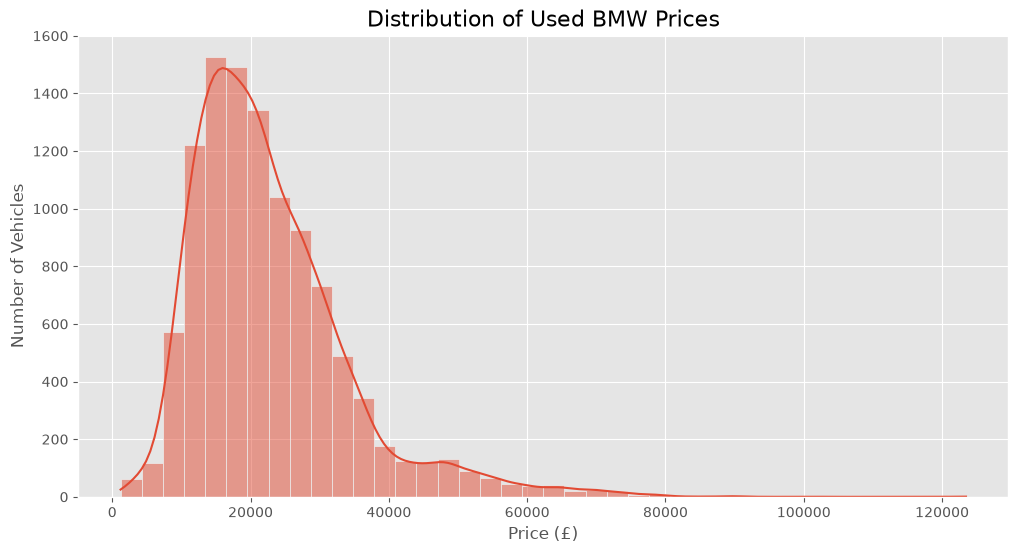

In [41]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Used BMW Prices", fontsize=16)

plt.xlabel("Price (£)")
plt.ylabel("Number of Vehicles")

plt.show()

### Interpretation

The histogram indicates that the distribution of vehicle prices is positively skewed.

Most vehicles are concentrated between approximately **£10,000 and £30,000**, while only a limited number of luxury BMW models are sold at substantially higher prices.

The long right tail suggests that the target variable is not normally distributed.

This observation indicates that a logarithmic transformation may improve the statistical properties of the target variable before regression modeling.

## 4.2 Skewness Analysis

Although the histogram provides a visual understanding of the distribution, skewness offers a quantitative measurement of asymmetry.

The skewness coefficient is calculated to determine whether the target variable deviates significantly from a normal distribution.

In [42]:
df["price"].skew()

np.float64(1.5868864681260946)

### Interpretation

The calculated skewness coefficient is approximately **1.59**.

Since the skewness value is greater than **1**, the distribution can be considered highly positively skewed.

This confirms the visual observation obtained from the histogram and supports the application of a logarithmic transformation before model development.

## 4.3 Outlier Detection Using Boxplot

Boxplots provide an effective visualization for detecting extreme observations.

Observations located outside the whiskers are considered potential outliers and may influence the performance of regression algorithms.

Therefore, a boxplot is generated to examine the presence of unusually expensive vehicles.

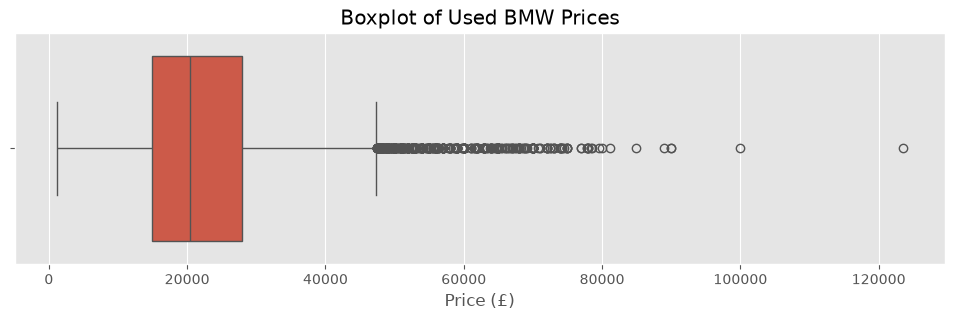

In [43]:
plt.figure(figsize=(12,3))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Used BMW Prices")

plt.xlabel("Price (£)")

plt.show()

### Interpretation

The boxplot clearly reveals the presence of several high-price observations located beyond the upper whisker.

These observations represent premium BMW models with substantially higher selling prices than the majority of the dataset.

Instead of immediately removing these observations, the project will apply the Interquartile Range (IQR) method to variables such as mileage and vehicle age, where extreme values are more likely to represent abnormal records rather than genuinely expensive vehicles.

# 5. Statistical Data Preprocessing



The quality of a machine learning model depends heavily on the quality of the input data.

Before training the regression models, several statistical preprocessing techniques were applied in order to improve data quality and reduce the influence of extreme observations.

The preprocessing stage includes:

- Feature engineering
- Logarithmic transformation
- Outlier detection using the Interquartile Range (IQR) method
- Construction of the final cleaned dataset

These steps ensure that the regression models are trained on statistically reliable data.

## 5.1 Feature Engineering

Feature engineering is the process of creating new variables that provide additional information to the machine learning model.

Instead of using only the manufacturing year, a new variable called **Vehicle Age** is created.

Vehicle age is expected to have a stronger relationship with selling price than the raw manufacturing year.

In [45]:
CURRENT_YEAR = 2026

df["car_age"] = CURRENT_YEAR - df["year"]

df[["year", "car_age"]].head()

,year,car_age
0,2014,12
1,2018,8
2,2016,10
3,2017,9
4,2014,12


### Interpretation

A new feature named **car_age** was generated from the manufacturing year.

Older vehicles generally experience greater depreciation than newer vehicles.

Therefore, the age of the vehicle is expected to be a more informative predictor for price estimation than the manufacturing year itself.

## 5.2 Distribution of Vehicle Age

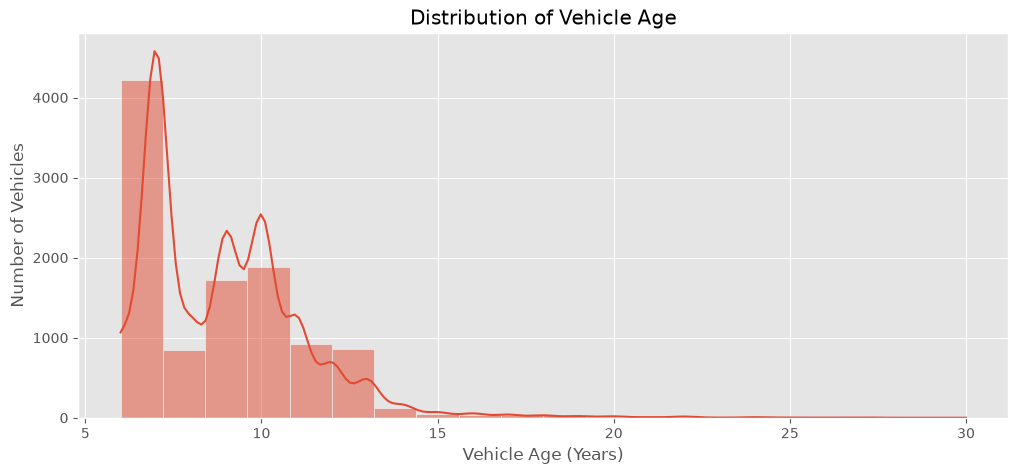

In [46]:
plt.figure(figsize=(12,5))

sns.histplot(
    df["car_age"],
    bins=20,
    kde=True
)

plt.title("Distribution of Vehicle Age")

plt.xlabel("Vehicle Age (Years)")

plt.ylabel("Number of Vehicles")

plt.show()

### Interpretation

The majority of vehicles are relatively new, with most observations concentrated between approximately two and ten years of age.

Understanding this distribution helps identify whether unusually old vehicles exist within the dataset.

## 5.3 Outlier Detection Using the IQR Method

Extreme observations may negatively influence regression models.

Instead of relying only on visual inspection, the Interquartile Range (IQR) method is used to statistically identify potential outliers.

The IQR method defines acceptable observations within the interval:

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

In [47]:
def remove_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    cleaned = data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]

    print("=" * 50)
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Removed Observations:", len(data)-len(cleaned))
    print("Remaining Observations:", len(cleaned))

    return cleaned

## 5.4 Mileage Outlier Analysis

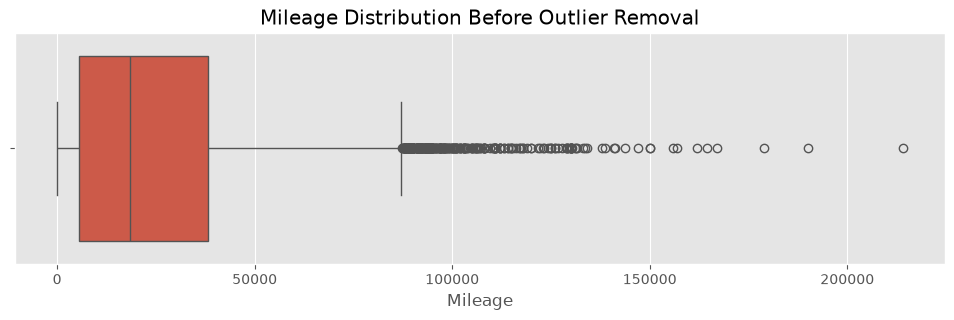

In [48]:
plt.figure(figsize=(12,3))

sns.boxplot(x=df["mileage"])

plt.title("Mileage Distribution Before Outlier Removal")

plt.xlabel("Mileage")

plt.show()

In [49]:
df_clean = remove_outliers_iqr(df, "mileage")

Column: mileage
Q1: 5529.0
Q3: 38206.0
IQR: 32677.0
Lower Bound: -43486.5
Upper Bound: 87221.5
Removed Observations: 296
Remaining Observations: 10485


### Interpretation

The mileage variable contains several observations outside the acceptable IQR interval.

These extreme mileage values were removed because they may represent unusual vehicles or data recording anomalies that could negatively influence the regression models.

## 5.5 Vehicle Age Outlier Analysis

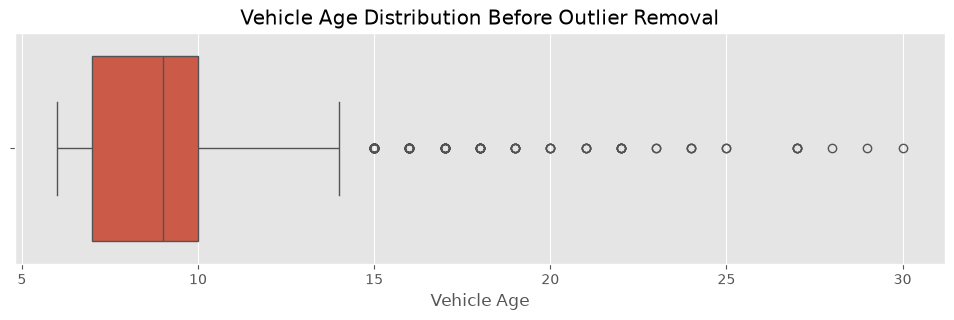

In [50]:
plt.figure(figsize=(12,3))

sns.boxplot(x=df_clean["car_age"])

plt.title("Vehicle Age Distribution Before Outlier Removal")

plt.xlabel("Vehicle Age")

plt.show()

In [51]:
df_clean = remove_outliers_iqr(df_clean, "car_age")

Column: car_age
Q1: 7.0
Q3: 10.0
IQR: 3.0
Lower Bound: 2.5
Upper Bound: 14.5
Removed Observations: 122
Remaining Observations: 10363


### Interpretation

The IQR method was also applied to the newly created vehicle age variable.

Removing unusually old vehicles helps reduce the influence of rare observations and improves the consistency of the training dataset.

## 5.6 Dataset After Statistical Cleaning

In [52]:
print("Original Dataset Shape :", df.shape)
print("Cleaned Dataset Shape  :", df_clean.shape)

Original Dataset Shape : (10781, 10)
Cleaned Dataset Shape  : (10363, 10)


In [53]:
comparison = pd.DataFrame({
    "Dataset": ["Original", "Cleaned"],
    "Number of Observations": [
        len(df),
        len(df_clean)
    ]
})

comparison

,Dataset,Number of Observations
0,Original,10781
1,Cleaned,10363


### Interpretation

After applying statistical preprocessing techniques, a cleaned version of the dataset was obtained.

Only observations identified as statistical outliers in mileage and vehicle age were removed.

The resulting dataset is expected to improve the robustness and predictive performance of the regression models.

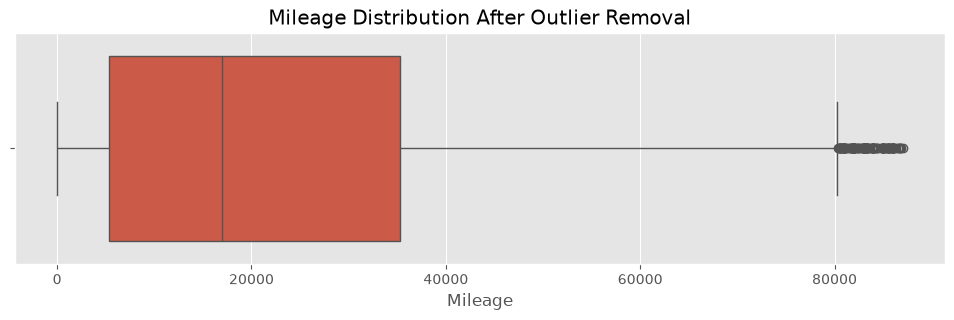

In [54]:
plt.figure(figsize=(12,3))

sns.boxplot(x=df_clean["mileage"])

plt.title("Mileage Distribution After Outlier Removal")

plt.xlabel("Mileage")

plt.show()

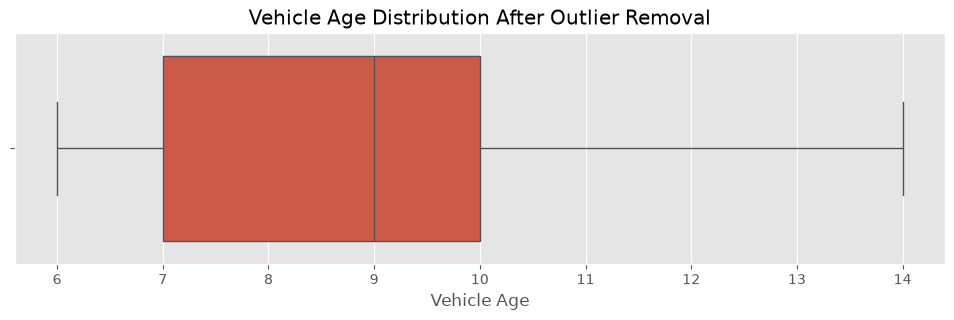

In [55]:
plt.figure(figsize=(12,3))

sns.boxplot(x=df_clean["car_age"])

plt.title("Vehicle Age Distribution After Outlier Removal")

plt.xlabel("Vehicle Age")

plt.show()

# 6. Data Preparation for Machine Learning

After completing the statistical preprocessing stage, the dataset is now ready for machine learning.

The objective of this section is to prepare the cleaned dataset for regression modeling.

The following steps will be performed:

- Define the target variable
- Separate input and output variables
- Identify categorical and numerical features
- Encode categorical variables
- Split the dataset into training and testing sets

These preprocessing steps ensure that the machine learning algorithms receive data in a format suitable for model training.

## 6.1 Selecting Features and Target Variable

Machine learning models require two components:

- **Features (X):** Independent variables used for prediction.
- **Target (y):** Dependent variable that the model learns to predict.

Since a logarithmic transformation was applied during preprocessing, the transformed variable (**log_price**) will be used as the prediction target instead of the original price.

In [56]:
X = df_clean.drop(["price", "log_price"], axis=1)

y = df_clean["log_price"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

KeyError: "['log_price'] not found in axis"

In [57]:
df_clean.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'car_age'],
      dtype='str')

In [58]:
df["log_price"] = np.log1p(df["price"])

In [59]:
df_clean = remove_outliers_iqr(df, "mileage")
df_clean = remove_outliers_iqr(df_clean, "car_age")

Column: mileage
Q1: 5529.0
Q3: 38206.0
IQR: 32677.0
Lower Bound: -43486.5
Upper Bound: 87221.5
Removed Observations: 296
Remaining Observations: 10485
Column: car_age
Q1: 7.0
Q3: 10.0
IQR: 3.0
Lower Bound: 2.5
Upper Bound: 14.5
Removed Observations: 122
Remaining Observations: 10363


In [60]:
df_clean.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'car_age', 'log_price'],
      dtype='str')

In [61]:
X = df_clean.drop(["price", "log_price"], axis=1)
y = df_clean["log_price"]

In [62]:
X = df_clean.drop(["price", "log_price"], axis=1)

y = df_clean["log_price"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (10363, 9)
Target Shape: (10363,)


### Interpretation

The original selling price was excluded from the feature matrix because it represents the prediction target.

Instead, the logarithmically transformed price (**log_price**) is used as the dependent variable to improve model stability and reduce the influence of skewness.

## 6.2 Feature Classification

The variables are divided into two groups:

### Categorical Variables

These variables describe categories and therefore require encoding before model training.

### Numerical Variables

These variables already contain numerical values and can be directly used by the regression models.

In [63]:
categorical_features = [
    "model",
    "transmission",
    "fuelType"
]

numerical_features = [
    "year",
    "mileage",
    "tax",
    "mpg",
    "engineSize",
    "car_age"
]

print("Categorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

Categorical Features
['model', 'transmission', 'fuelType']

Numerical Features
['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age']


### Interpretation

The dataset contains three categorical variables and six numerical variables.

Since regression algorithms cannot directly interpret categorical values, these variables must be transformed into numerical representations using an encoding technique.

## 6.3 One-Hot Encoding

Machine learning algorithms cannot process text values such as vehicle models or transmission types.

Therefore, **One-Hot Encoding** is applied.

This method converts each category into binary indicator variables without introducing any artificial numerical ordering between categories.

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

### Why One-Hot Encoding?

One-Hot Encoding is one of the most widely used preprocessing techniques for categorical variables.

Unlike label encoding, it does not create an artificial ranking between categories, making it particularly suitable for tree-based regression algorithms such as Random Forest and XGBoost.

## 6.4 Train-Test Split

To evaluate model performance fairly, the cleaned dataset is divided into two subsets.

- **Training Set (80%)**
  Used for learning the relationships between features and the target variable.

- **Testing Set (20%)**
  Used exclusively to evaluate the predictive performance of the trained models.

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (8290, 9)
Testing Features  : (2073, 9)

Training Target : (8290,)
Testing Target  : (2073,)


### Interpretation

The cleaned dataset was randomly divided into training and testing subsets.

A random state of **42** was specified to ensure reproducibility, allowing the experiment to produce identical results in future executions.

The training dataset will be used for model development, while the testing dataset will remain unseen until the evaluation stage.

# 7. Model Development

After completing the preprocessing stage, the cleaned dataset is now ready for regression modeling.

In this section, two different machine learning algorithms will be trained and compared:

- Random Forest Regressor
- Extreme Gradient Boosting (XGBoost)

Both algorithms are ensemble learning methods that are widely used for regression problems because of their ability to model complex non-linear relationships.

## 7.1 Random Forest Regressor

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions.

Compared with a single decision tree, Random Forest generally provides:

- Higher prediction accuracy
- Better generalization
- Lower risk of overfitting

For these reasons, it is frequently used as a baseline model in regression problems.

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model",

         RandomForestRegressor(

             n_estimators=300,

             random_state=42

         ))

    ]

)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['model','year','transmission',...,'mpg','engineSize','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of co

### Interpretation

The Random Forest model has been successfully trained using the training dataset.

During training, categorical variables were automatically encoded through the preprocessing pipeline before the regression model was fitted.

## 7.2 Random Forest Prediction

In [68]:
rf_pred_log = rf_model.predict(X_test)

rf_y_test = np.expm1(y_test)

rf_pred = np.expm1(rf_pred_log)

### Why Reverse the Log Transformation?

The regression model predicts logarithmic prices because the target variable was transformed before training.

To evaluate prediction errors in the original price scale (£), the logarithmic predictions are converted back using the inverse exponential transformation.

## 7.3 Random Forest Performance Evaluation

The performance of the regression model is evaluated using three different metrics.

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

In [69]:
rf_mae = mean_absolute_error(
    rf_y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        rf_y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    rf_y_test,
    rf_pred
)

print("Random Forest Results")
print("---------------------")

print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R²  :", round(rf_r2,4))

Random Forest Results
---------------------
MAE : 1571.58
RMSE: 2551.91
R²  : 0.95


### Metric Interpretation

**Mean Absolute Error (MAE)**

Represents the average prediction error in pounds (£).

Smaller values indicate better prediction accuracy.

---

**Root Mean Squared Error (RMSE)**

Measures the magnitude of prediction errors while penalizing large errors more heavily.

Lower RMSE values indicate a better-performing regression model.

---

**Coefficient of Determination (R²)**

Represents the proportion of variance explained by the regression model.

Values closer to **1** indicate stronger predictive performance.

## 7.4 XGBoost Regressor

Extreme Gradient Boosting (XGBoost) is one of the most powerful ensemble algorithms used in modern machine learning.

Compared with Random Forest, XGBoost usually provides:

- Better predictive performance
- Improved handling of complex feature interactions
- Strong regularization against overfitting

For these reasons, XGBoost has become one of the most popular algorithms in machine learning competitions.

In [70]:
xgb_model = Pipeline(

    steps=[

        ("preprocessor",

         preprocessor),

        ("model",

         XGBRegressor(

             n_estimators=400,

             learning_rate=0.05,

             max_depth=5,

             random_state=42

         ))

    ]

)

xgb_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['model','year','transmission',...,'mpg','engineSize','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of co

## 7.5 XGBoost Prediction

In [71]:
xgb_pred_log = xgb_model.predict(X_test)

xgb_y_test = np.expm1(y_test)

xgb_pred = np.expm1(xgb_pred_log)

In [72]:
xgb_mae = mean_absolute_error(
    xgb_y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        xgb_y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    xgb_y_test,
    xgb_pred
)

print("XGBoost Results")
print("----------------")

print("MAE :", round(xgb_mae,2))
print("RMSE:", round(xgb_rmse,2))
print("R²  :", round(xgb_r2,4))

XGBoost Results
----------------
MAE : 1529.62
RMSE: 2323.31
R²  : 0.9585


### Interpretation

The XGBoost model was evaluated using the same performance metrics as the Random Forest model.

This allows a direct comparison between the two regression algorithms under identical testing conditions.

# 8. Model Comparison and Selection

After training both regression models, their performances are compared using the same evaluation metrics.

The objective of this section is to determine which model provides better predictive performance on the test dataset.

The models are compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

A lower MAE and RMSE indicate better prediction accuracy, while a higher R² value indicates that the model explains a larger proportion of the variance in vehicle prices.

## 8.1 Creating the Model Comparison Table

In [73]:
model_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [rf_mae, xgb_mae],
    "RMSE": [rf_rmse, xgb_rmse],
    "R2 Score": [rf_r2, xgb_r2]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Random Forest,1571.578552,2551.909979,0.949970
1,XGBoost,1529.617081,2323.311104,0.958532


### Interpretation

The model comparison table allows a direct evaluation of Random Forest and XGBoost.

The model with the lower MAE and RMSE values makes more accurate price predictions.

The model with the higher R² score explains a larger proportion of the variation in used BMW prices.

## 8.2 Visual Comparison of Model Performance

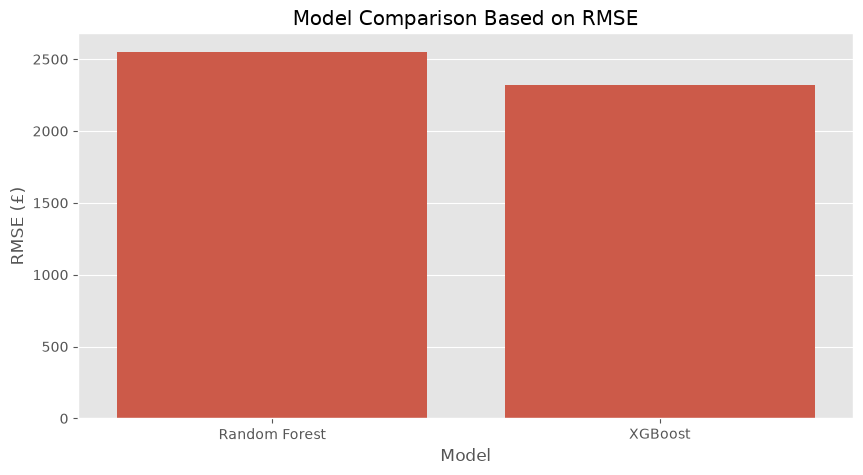

In [74]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (£)")

plt.show()

### Interpretation

RMSE was selected as the main comparison metric because it penalizes larger prediction errors more strongly than MAE.

This is especially important in price prediction problems, where large estimation errors can significantly reduce the reliability of the model.

## 8.3 Selecting the Best Model

In [75]:
if xgb_rmse < rf_rmse:
    best_model = xgb_model
    best_model_name = "XGBoost"
else:
    best_model = rf_model
    best_model_name = "Random Forest"

print("Best Model:", best_model_name)

Best Model: XGBoost


### Interpretation

The best-performing model was selected based on the lowest RMSE value.

RMSE was preferred as the main selection criterion because it is sensitive to large prediction errors and therefore provides a stricter evaluation of model performance.

## 8.4 Saving the Best Model

The selected model is saved using Joblib so that it can later be used in the Streamlit web application.

Saving the model prevents the need to retrain it every time the application is launched.

In [76]:
joblib.dump(best_model, "bmw_price_model.pkl")

['bmw_price_model.pkl']

### Interpretation

The best-performing model was successfully saved as a `.pkl` file.

This file will be loaded inside the Streamlit application to generate real-time price predictions based on user inputs.

## 8.5 Actual vs Predicted Prices

In [77]:
if best_model_name == "XGBoost":
    best_predictions = xgb_pred
else:
    best_predictions = rf_pred

actual_vs_predicted = pd.DataFrame({
    "Actual Price": np.expm1(y_test),
    "Predicted Price": best_predictions
})

actual_vs_predicted.head()

,Actual Price,Predicted Price
4976,18990.0,19243.208984
8478,17979.0,19264.251953
6020,18495.0,19000.605469
1191,10985.0,10998.466797
3442,34980.0,34661.113281


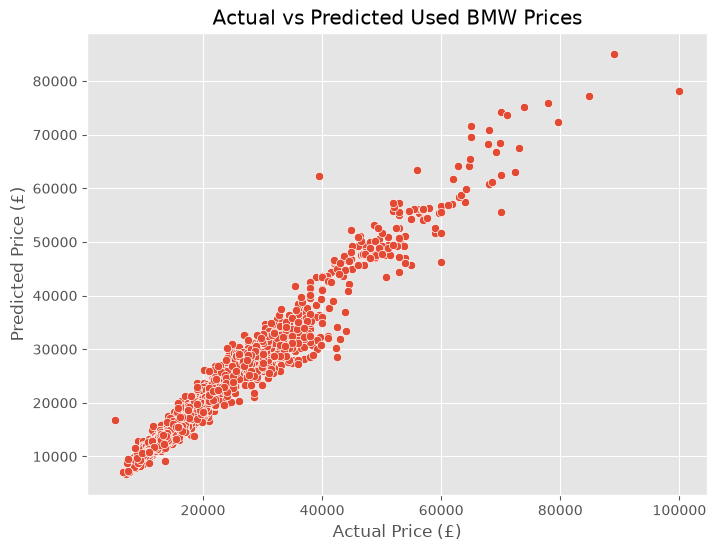

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=actual_vs_predicted,
    x="Actual Price",
    y="Predicted Price"
)

plt.title("Actual vs Predicted Used BMW Prices")
plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")

plt.show()

### Interpretation

The scatter plot compares actual vehicle prices with model predictions.

If the model performs well, most observations should be located close to a diagonal line where actual and predicted prices are approximately equal.

Large deviations from this pattern indicate prediction errors.

## 8.6 Final Summary of Model Performance

The results show that both ensemble models are capable of predicting used BMW prices with reasonable accuracy.

However, the final model selection is based on overall predictive performance, especially RMSE and R².

The selected model will be used in the deployment stage of the project.

# 9. Model Export and Future Deployment

Developing an accurate machine learning model is an important part of a real-world data science project. However, in practical applications, the trained model should also be saved and prepared for future deployment.

In this project, the best-performing regression model was exported using the Joblib library. This allows the model to be reused later without retraining it from the beginning.

The saved model can be integrated into future applications, such as a Streamlit web application, where users can enter vehicle specifications and receive an estimated selling price.

## 9.1 Saving the Final Model

The final trained model was saved as a `.pkl` file using the Joblib library.

```python
joblib.dump(best_model, "bmw_price_model.pkl")
```

Output:

```python
['bmw_price_model.pkl']
```

Saving the trained model improves efficiency by eliminating the need to retrain the model every time a prediction is required.

## 9.2 Future Deployment

Although a web application is not included in this project, the exported model is fully prepared for future deployment.

The saved model can later be integrated into a Streamlit application or another web framework to provide an interactive interface for end users.

Such an application could allow users to enter the following vehicle information:

- BMW Model
- Manufacturing Year
- Mileage
- Fuel Type
- Transmission
- Road Tax
- Fuel Economy (MPG)
- Engine Size

The trained regression model would then process these inputs and estimate the expected selling price of the vehicle in real time.